## 01 Data Exploration 

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv('../datasets/raw/TMDB  IMDB Movies Dataset.csv')

df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,genres,production_companies,production_countries,spoken_languages,keywords,directors,writers,averageRating,numVotes,cast
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",Christopher Nolan,Christopher Nolan,8.8,2802298,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan",8.7,2505104,"Matthew McConaughey, Anne Hathaway, Michael Ca..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...",9.1,3152332,"Christian Bale, Heath Ledger, Aaron Eckhart, M..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",James Cameron,James Cameron,7.9,1491747,"Sam Worthington, Zoe Saldaña, Sigourney Weaver..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",Joss Whedon,"Joss Whedon, Zak Penn",8.0,1552427,"Robert Downey Jr., Chris Evans, Mark Ruffalo, ..."


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 436482 entries, 0 to 436481
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    436482 non-null  int64  
 1   title                 436482 non-null  str    
 2   vote_average          436482 non-null  float64
 3   vote_count            436482 non-null  int64  
 4   status                436482 non-null  str    
 5   release_date          415099 non-null  str    
 6   revenue               436482 non-null  int64  
 7   runtime               436482 non-null  int64  
 8   adult                 436482 non-null  bool   
 9   backdrop_path         185296 non-null  str    
 10  budget                436482 non-null  int64  
 11  homepage              54780 non-null   str    
 12  tconst                436482 non-null  str    
 13  original_language     436482 non-null  str    
 14  original_title        436482 non-null  str    
 15  overview   

Ada data yg missing di bagian overview dan bagian genre yg mana ini sangat penting buat model nantinya 

In [4]:
df.isnull().sum()

id                           0
title                        0
vote_average                 0
vote_count                   0
status                       0
release_date             21383
revenue                      0
runtime                      0
adult                        0
backdrop_path           251186
budget                       0
homepage                381702
tconst                       0
original_language            0
original_title               0
overview                 42983
popularity                   0
poster_path              75923
tagline                 344291
genres                   79727
production_companies    174595
production_countries    115785
spoken_languages        104410
keywords                265795
directors                 9947
writers                  65027
averageRating                0
numVotes                     0
cast                     68813
dtype: int64

Ada beberapa feature penting yang mempunyai missing value, feature tersebut berupa genre dan overview

#### Data cleaning 

In [5]:
df_cleaned = df.dropna(subset=['overview', 'genres'], how='any')

print(f"Panjang data awal = {len(df)}")
print(f"Panjang data bersih = {len(df_cleaned)}")

Panjang data awal = 436482
Panjang data bersih = 325967


In [6]:
df_cleaned.to_csv('../datasets/processed/movies_dataset_final_cleaned.csv', index=False)

In [7]:
df = pd.read_csv('../datasets/processed/movies_dataset_final_cleaned.csv')

df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,genres,production_companies,production_countries,spoken_languages,keywords,directors,writers,averageRating,numVotes,cast
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",Christopher Nolan,Christopher Nolan,8.8,2802298,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan",8.7,2505104,"Matthew McConaughey, Anne Hathaway, Michael Ca..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...",9.1,3152332,"Christian Bale, Heath Ledger, Aaron Eckhart, M..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",James Cameron,James Cameron,7.9,1491747,"Sam Worthington, Zoe Saldaña, Sigourney Weaver..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",Joss Whedon,"Joss Whedon, Zak Penn",8.0,1552427,"Robert Downey Jr., Chris Evans, Mark Ruffalo, ..."


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 325967 entries, 0 to 325966
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    325967 non-null  int64  
 1   title                 325967 non-null  str    
 2   vote_average          325967 non-null  float64
 3   vote_count            325967 non-null  int64  
 4   status                325967 non-null  str    
 5   release_date          322042 non-null  str    
 6   revenue               325967 non-null  int64  
 7   runtime               325967 non-null  int64  
 8   adult                 325967 non-null  bool   
 9   backdrop_path         167654 non-null  str    
 10  budget                325967 non-null  int64  
 11  homepage              49819 non-null   str    
 12  tconst                325967 non-null  str    
 13  original_language     325967 non-null  str    
 14  original_title        325967 non-null  str    
 15  overview   

In [9]:
df.isnull().sum()

id                           0
title                        0
vote_average                 0
vote_count                   0
status                       0
release_date              3925
revenue                      0
runtime                      0
adult                        0
backdrop_path           158313
budget                       0
homepage                276148
tconst                       0
original_language            0
original_title               0
overview                     0
popularity                   0
poster_path              37361
tagline                 241840
genres                       0
production_companies     98295
production_countries     54358
spoken_languages         47163
keywords                170860
directors                 6118
writers                  42698
averageRating                0
numVotes                     0
cast                     38133
dtype: int64

In [10]:
print(f'jumlah data duplikat = {df.duplicated().sum()}')

jumlah data duplikat = 0


#### Univariate Analysis

##### 1. Distribusi jumlah kata di overview 

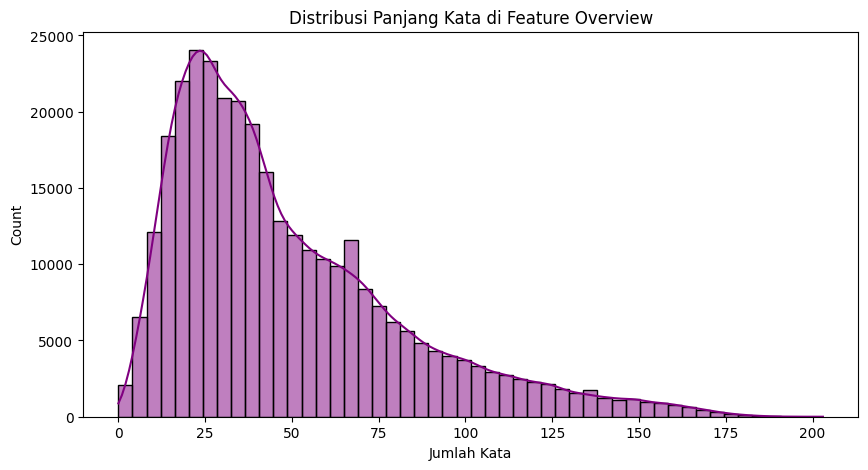

Rata-rata panjang kata : 48.848846662392205


In [11]:
df['word_count'] = df['overview'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50, kde=True, color='purple')
plt.title('Distribusi Panjang Kata di Feature Overview')
plt.xlabel('Jumlah Kata')
plt.show()

print(f"Rata-rata panjang kata : {df['word_count'].mean()}")

##### 2. Genre Distribution 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_34232\1514728548.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(genre_counts.values())[:15], y=list(genre_counts.keys())[:15], palette='viridis')


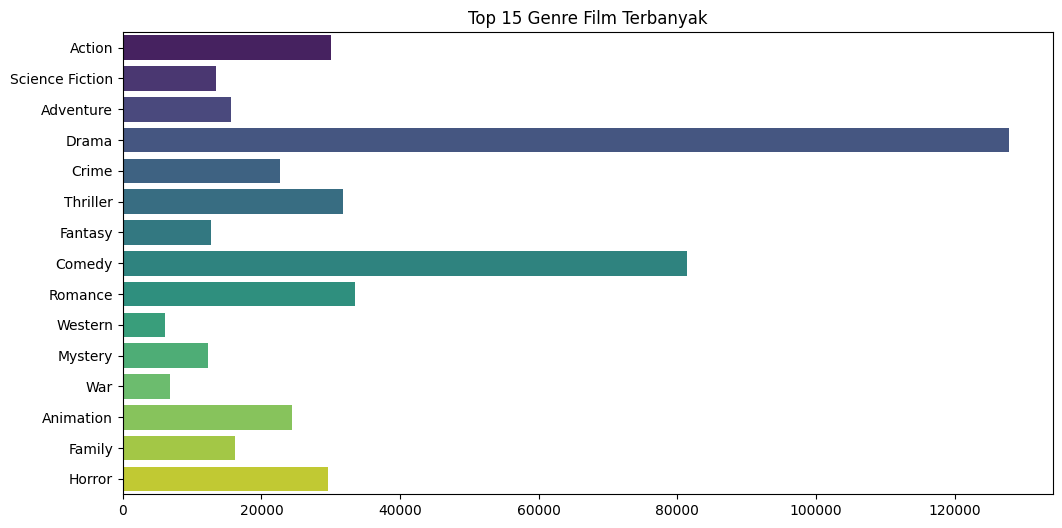

In [12]:
from collections import Counter

all_genres = []
df['genres'].apply(lambda x: all_genres.extend(x.split(', ')))
genre_counts = Counter(all_genres)

#Plotting top 15 genres
plt.figure(figsize=(12,6))
sns.barplot(x=list(genre_counts.values())[:15], y=list(genre_counts.keys())[:15], palette='viridis')
plt.title('Top 15 Genre Film Terbanyak')
plt.show()

#### Bivariat & Multivariate

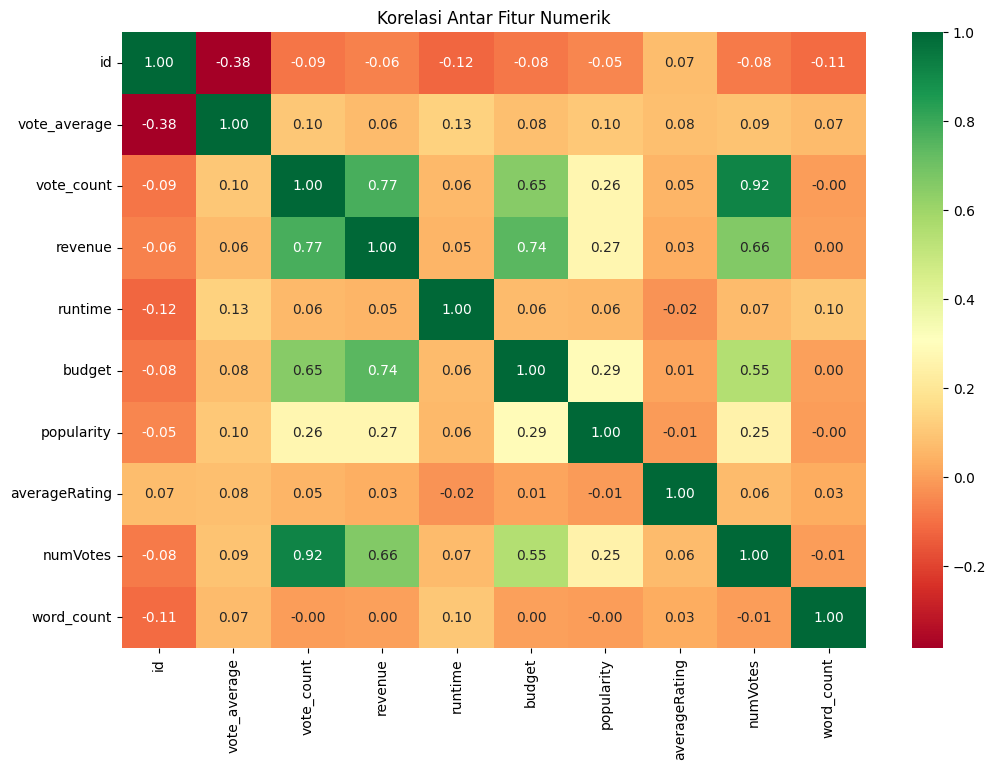

In [13]:

# Heatmap Korelasi buat kolom numerik
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Korelasi Antar Fitur Numerik')
plt.show()

### Feature Selection 

In [14]:
columns_to_keep = [
    'id', 'title', 'overview', 'genres', 'keywords', 
    'directors', 'cast', 'poster_path', 'vote_average', 
    'popularity', 'release_date'
]

df_selected = df_cleaned[columns_to_keep].copy()

In [15]:
text_features = ['keywords', 'directors', 'cast']
for col in text_features:
    df_selected[col] = df_selected[col].fillna('')

In [16]:
df_selected['poster_path'] = df_selected['poster_path'].fillna('')
df_selected['release_date'] = df_selected['release_date'].fillna('Unknown')

### Feature fusion untuk mempermudah DistilBERT 

In [17]:
df_selected['content'] = (
    df_selected['title'] + " " + 
    df_selected['overview'] + " " + 
    df_selected['genres'] + " " + 
    df_selected['keywords'] + " " + 
    df_selected['directors'] + " " + 
    df_selected['cast']
)

In [18]:
df_selected['content'] = df_selected['content'].apply(lambda x: " ".join(x.split()))

In [19]:
print(df_selected[['title', 'content']].head())

             title                                            content
0        Inception  Inception Cobb, a skilled thief who commits co...
1     Interstellar  Interstellar The adventures of a group of expl...
2  The Dark Knight  The Dark Knight Batman raises the stakes in hi...
3           Avatar  Avatar In the 22nd century, a paraplegic Marin...
4     The Avengers  The Avengers When an unexpected enemy emerges ...


In [20]:
output_path = '../datasets/processed/movies_dataset_ready.csv'

df_selected.to_csv(output_path, index=False)


In [5]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('../datasets/processed/movies_dataset_ready.csv')

# --- BEFORE UNDERSAMPLING ---
print("="*40)
print(f"📊 Total records BEFORE undersampling: {len(df)}")
print("="*40 + "\n")

# Convert the genres string into a list
df['genre_list'] = df['genres'].apply(lambda x: x.split(', ') if isinstance(x, str) else [])

majority_genres = ['Drama', 'Comedy']

def is_pure_majority(genres):
    # If the list is empty, do not classify it as a majority genre
    if len(genres) == 0:
        return False
    return all(g in majority_genres for g in genres)

mask = df['genre_list'].apply(is_pure_majority)
df_majority = df[mask] 
df_minority = df[~mask] 

print("🔍 Breakdown before undersampling:")
print(f"  - Majority records (Exclusively Drama/Comedy): {len(df_majority)}")
print(f"  - Minority records (Contains other genres): {len(df_minority)}\n")

# Downsample the majority class to 40,000 records
df_majority_sampled = df_majority.sample(n=40000, random_state=42)

# Concatenate and shuffle the dataset
df_balanced = pd.concat([df_minority, df_majority_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

# --- AFTER UNDERSAMPLING ---
print("="*40)
print(f"📉 Total records AFTER undersampling: {len(df_balanced)}")
print("="*40 + "\n")

# Save the balanced dataset
df_balanced.to_csv('../datasets/processed/movies_balanced.csv', index=False)
print("Undersampling process completed successfully! 🏋️‍♂️")

📊 Total records BEFORE undersampling: 325967

🔍 Breakdown before undersampling:
  - Majority records (Exclusively Drama/Comedy): 89089
  - Minority records (Contains other genres): 236878

📉 Total records AFTER undersampling: 276878

Undersampling process completed successfully! 🏋️‍♂️


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24740\1536328119.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(genre_counts.values())[:15], y=list(genre_counts.keys())[:15], palette='viridis')


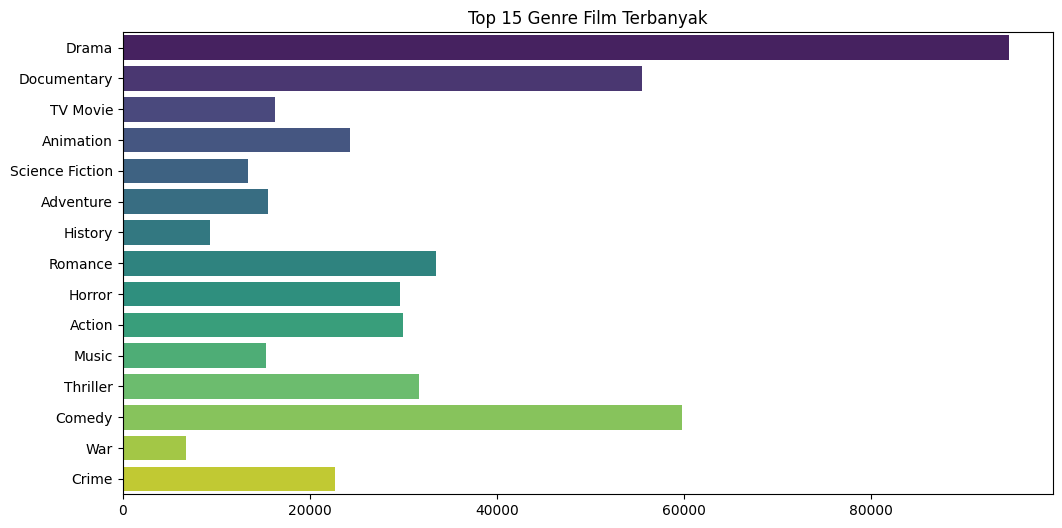

In [7]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

from collections import Counter

df_balance = pd.read_csv("../datasets/processed/movies_balanced.csv")
all_genres = []
df_balance['genres'].apply(lambda x: all_genres.extend(x.split(', ')))
genre_counts = Counter(all_genres)

#Plotting top 15 genres
plt.figure(figsize=(12,6))
sns.barplot(x=list(genre_counts.values())[:15], y=list(genre_counts.keys())[:15], palette='viridis')
plt.title('Top 15 Genre Film Terbanyak')
plt.show()

In [3]:
import os
import pandas as pd

# Resolve the directory layout (stepping up one level from the 'notebooks' folder)
notebook_dir = os.getcwd()
base_dir = os.path.dirname(notebook_dir)

# Construct absolute system paths
input_path = os.path.join(base_dir, "datasets", "processed", "movies_balanced.csv")
output_path = os.path.join(base_dir, "datasets", "processed", "movies_40k.csv")

print("Initializing data verification...")
print(f"Input Path Target:  {input_path}")
print(f"Output Path Target: {output_path}")
print("-" * 50)

try:
    # Load the original baseline data
    print("Loading original dataset...")
    df = pd.read_csv(input_path)
    print(f"Initial row count: {len(df)}")
    
    # Execute random downsampling to the 40,000 threshold
    print("Executing random sampling to 40,000 rows...")
    df_40k = df.sample(n=40000, random_state=42).reset_index(drop=True)
    
    # Export the processed sample to disk
    print("Exporting processed file to target directory...")
    df_40k.to_csv(output_path, index=False)
    print(f"Process completed successfully. Target dataset saved to: {output_path}")

except FileNotFoundError as e:
    print(f"Execution Error: Please verify that the source file exists at the designated path.\nDetails: {e}")

Initializing data verification...
Input Path Target:  d:\College Life\Semester 6\Project Data Mining\project\datasets\processed\movies_balanced.csv
Output Path Target: d:\College Life\Semester 6\Project Data Mining\project\datasets\processed\movies_40k.csv
--------------------------------------------------
Loading original dataset...
Initial row count: 276878
Executing random sampling to 40,000 rows...
Exporting processed file to target directory...
Process completed successfully. Target dataset saved to: d:\College Life\Semester 6\Project Data Mining\project\datasets\processed\movies_40k.csv


C:\Users\ASUS\AppData\Local\Temp\ipykernel_36260\3629539388.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(genre_counts.values())[:15], y=list(genre_counts.keys())[:15], palette='viridis')


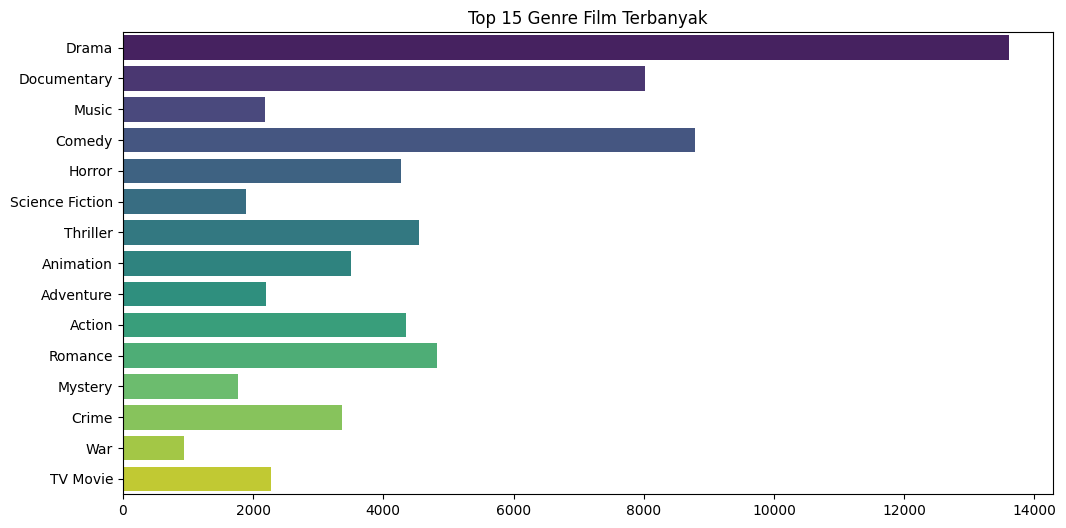

In [4]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

from collections import Counter

df_balance = pd.read_csv("../datasets/processed/movies_40k.csv")
all_genres = []
df_balance['genres'].apply(lambda x: all_genres.extend(x.split(', ')))
genre_counts = Counter(all_genres)

#Plotting top 15 genres
plt.figure(figsize=(12,6))
sns.barplot(x=list(genre_counts.values())[:15], y=list(genre_counts.keys())[:15], palette='viridis')
plt.title('Top 15 Genre Film Terbanyak')
plt.show()